### Stwp 1: Import libraries. ###

In [80]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [82]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.17.0


### Step 2: Data Exloration (EDA) and Cleaning ###

In [89]:
#-- Load dataset --#
df = pd.read_csv('../Processed/efficiency_stations.csv')
print("✅ Dataset loaded successfully!")

#-- Check for first 5 rows. --#
print("First 5 rows of the dataset:")
display(df.head())

#-- Check for missing values. --#
print("\n--- Missing Values ---")
print(df.isnull().sum())

#-- Descriptive Statistics. --#
print("\n--- Descriptive Statistics ---")
display(df.describe())

#-- Check unique stations. --#
n_stations = df['tfm_id'].nunique()
print(f"\n📊 Total unique stations: {n_stations}")

✅ Dataset loaded successfully!
First 5 rows of the dataset:


,x,y,fid,objectid,tfm_id,tfm_desc,tfm_typ_de,movement_t,site_desc,road_nbr,...,time_categ,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_name,road_avg_aadt,efficiency_index,vs_average_pct
0,144.560081,-37.968598,45122,45324,42013,PRINCES FWY WB ON-RAMP FROM SOUTH RD,MIDBLOCK,On Ramp,PRINCES FWY ON-RAMP FROM SOUTH RD,7024,...,Greater than 10 Years,18,1998,40,0,0.21,160 SOUTH ROADB 2500F,40.0,1.00,0.0
1,145.088615,-37.881431,55947,55189,52075,MONASH FWY OUTBOUND OFFRAMP TO WARRIGAL RD,INTERSECTION,Off Ramp,SVO_Map_LTD:838||SITE DESC: MONASH FWY OUTBOUN...,7138,...,Between 5 and 10 Years,10,2006,13000,0,0.00,2000F 2070B,5350.0,2.43,143.0
2,145.090058,-37.882231,38735,38966,36894,S.E.ARTERIAL OFF RAMP NW OF WARRIGAL RD,INTERSECTION,Off Ramp,S.E.ARTERIAL SEBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,19,1997,8400,640,0.08,2000F 2070B,5350.0,1.57,57.0
3,145.088615,-37.881431,23193,23092,54241,S.E.ARTERIAL ON RAMP NW OF WARRIGAL RD,INTERSECTION,On Ramp,S.E.ARTERIAL NWBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,0,0,0,0,0.00,2000F 2070B,5350.0,0.00,-100.0
4,145.222981,-37.957762,6407,6604,9101,MONASH FWY OFF RAMP SEBD TO STUD RD,INTERSECTION,Off Ramp,MONASH FWY OFF RAMP STO STUD RD,7144,...,Between 5 and 10 Years,9,2007,8600,830,0.10,2000F 2090B,5625.0,1.53,53.0



--- Missing Values ---
x                     0
y                     0
fid                   0
objectid              0
tfm_id                0
tfm_desc              0
tfm_typ_de            0
movement_t            4
site_desc             0
road_nbr              0
declared_r            0
local_road            0
data_src_c            0
data_sourc            0
time_categ            0
year_since            0
last_year             0
aadt_allve            0
aadt_truck            0
per_trucks            0
road_name             0
road_avg_aadt         0
efficiency_index    124
vs_average_pct      124
dtype: int64

--- Descriptive Statistics ---


,x,y,fid,objectid,tfm_id,road_nbr,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_avg_aadt,efficiency_index,vs_average_pct
count,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3380.000000,3380.000000
mean,144.885816,-37.618559,29251.699772,29255.088470,34928.537671,5712.319920,9.083048,1849.273116,9241.475457,316.523973,0.071084,3792.222506,2.507216,150.721598
std,1.108772,0.653601,17322.943085,17325.283422,17813.028835,1302.156041,8.524366,538.748641,13472.587225,766.941098,0.085459,4777.952398,1.880504,188.050390
min,140.973775,-38.937510,7.000000,9.000000,32.000000,2000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,144.609591,-37.938190,16194.750000,16185.500000,22624.250000,5169.750000,2.000000,1997.000000,500.000000,0.000000,0.000000,415.000000,1.200000,20.000000
50%,144.972681,-37.794672,27571.000000,27599.000000,38534.500000,5582.000000,6.000000,2008.000000,4800.000000,30.000000,0.050000,2212.000000,2.030000,103.000000
75%,145.193167,-37.572633,45638.750000,45626.750000,50026.250000,7028.000000,16.000000,2013.000000,12000.000000,280.000000,0.110000,5400.000000,3.325000,232.500000
max,149.739929,-34.178459,57932.000000,57939.000000,61068.000000,9999.000000,31.000000,2016.000000,123000.000000,11000.000000,0.690000,42610.000000,23.000000,2200.000000



📊 Total unique stations: 3504


✅ Save correelation matrix at: ../Figures/feature_correlation.png


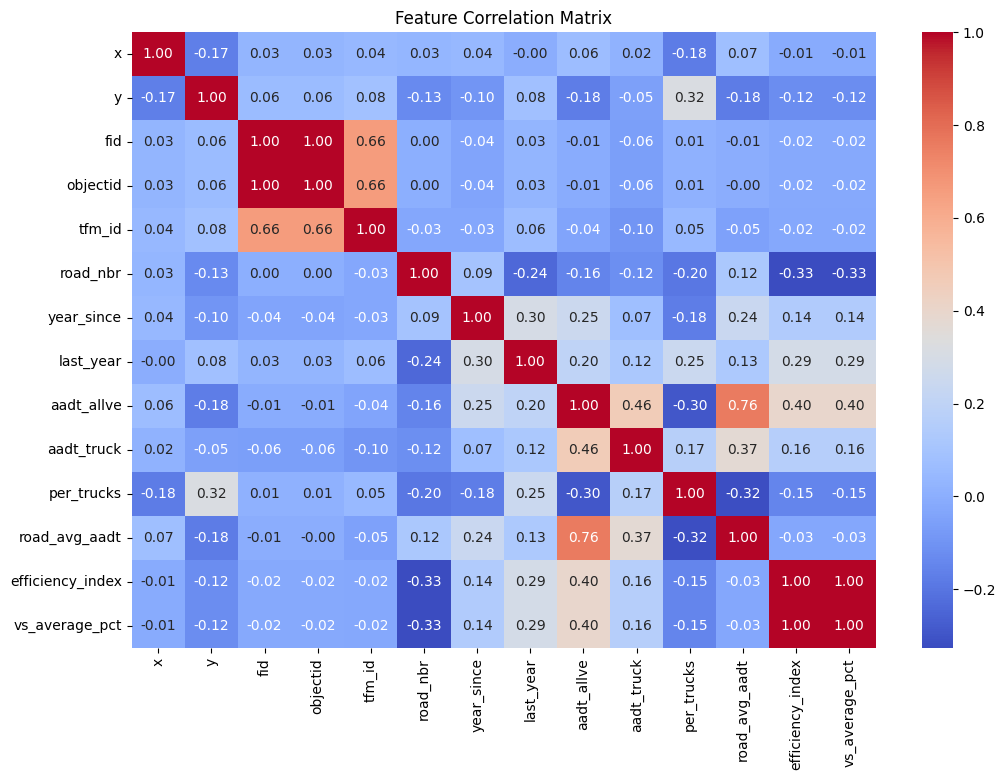

In [90]:
folder_path = '../Figures/'

#-- Correlation Matric. --#
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')\

corr_path = os.path.join(folder_path, "feature_correlation.png")
plt.savefig(corr_path, dpi=300, bbox_inches='tight')
print(f"✅ Save correelation matrix at: {corr_path}")
plt.show()

✅ Đã lưu biểu đồ phân phối tại: ../Figures/target_distribution.png


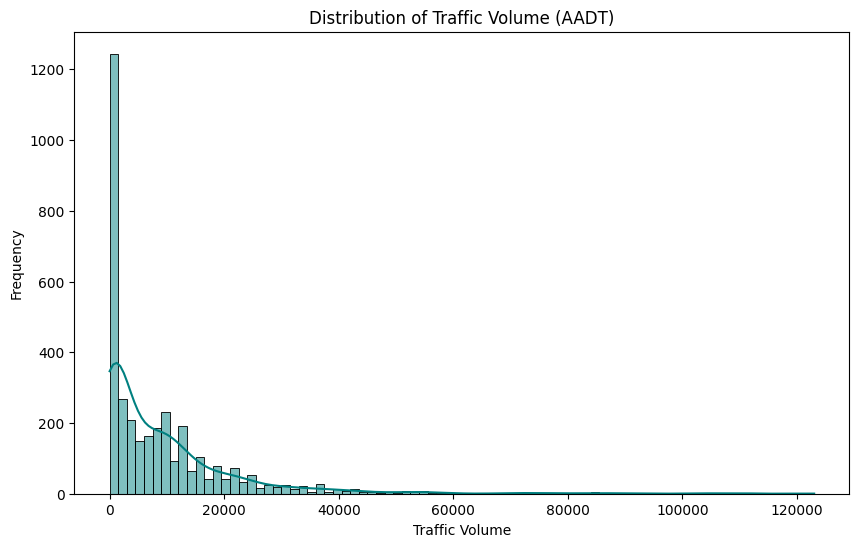

In [91]:
#-- Target Distribution Display. --#
plt.figure(figsize=(10, 6))
sns.histplot(df['aadt_allve'], kde=True, color='teal')
plt.title('Distribution of Traffic Volume (AADT)')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')

dist_path = os.path.join(folder_path, "target_distribution.png")
plt.savefig(dist_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ phân phối tại: {dist_path}")
plt.show()

✅ Đã lưu biểu đồ Boxplot tại: ../Figures/features_boxplot.png


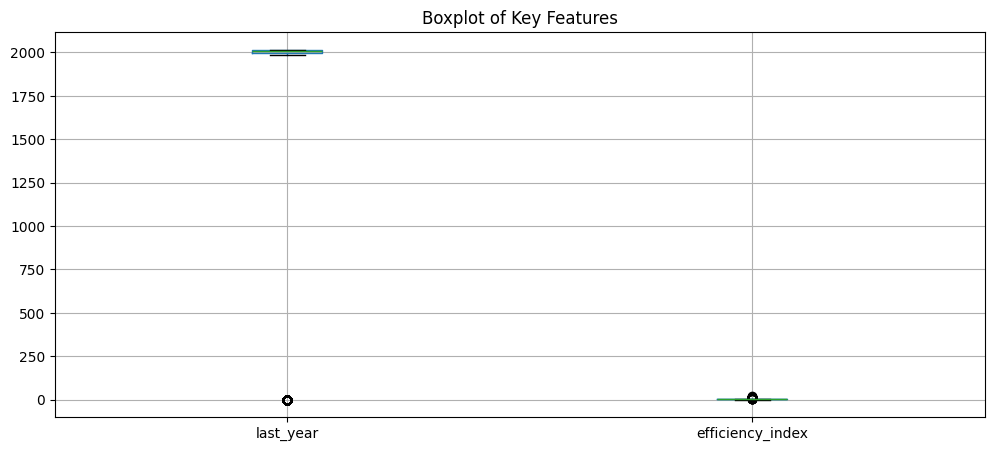

In [92]:
important_features = ['last_year', 'efficiency_index']
plt.figure(figsize=(12, 5))
df[important_features].boxplot()
plt.title('Boxplot of Key Features')

# Lưu hình
box_path = os.path.join(folder_path, "features_boxplot.png")
plt.savefig(box_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ Boxplot tại: {box_path}")
plt.show()

### Step 3: Data Processing and Squence Creation ###

In [94]:
#-- Define feature columns and the target variable. --#
feature_cols = ['x', 'y', 'last_year', 'efficiency_index'] 
target_col = 'aadt_allve'

#-- Sort data. --#
df_sorted = df.sort_values(by=['tfm_id', 'last_year']).reset_index(drop=True)

#-- Sliding window function. --#    
def create_sequences(X, y, seq_length=8):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        #-- Extract a window of 'seq_length' years as input features. --#
        X_seq.append(X[i : i + seq_length])
        #-- The value at 'i + seq_length' is our target to predict. --#
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

#-- Generate sequences for each unique station. --#
all_X_list = []
all_y_list = []
lookback_window = 8

for station_id, group in df_sorted.groupby('tfm_id'):
    #--- Only process stations with enough historical data. --#
    if len(group) > lookback_window:
        #-- Features: (x, y, year, efficiency). --#
        station_features = group[feature_cols].values
        #-- Target: Log-transform the traffic volume to normalize distribution. --#
        station_target = np.log1p(group[target_col].values) 
        
        #-- Create sequences using the sliding window function. --#
        X_temp, y_temp = create_sequences(station_features, station_target, seq_length=lookback_window)
        
        all_X_list.extend(X_temp)
        all_y_list.extend(y_temp)

#-- Convert lists to Final Numpy Arrays for Deep Learning. --#
X_seq = np.array(all_X_list)
y_seq = np.array(all_y_list)

print("--- Data Preprocessing Summary ---")
print(f"Total Sequences Created: {len(X_seq)}")
print(f"Input Shape (X_seq): {X_seq.shape}") # Expected: (Total Samples, 8, 4)
print(f"Target Shape (y_seq): {y_seq.shape}")

--- Data Preprocessing Summary ---
Total Sequences Created: 0
Input Shape (X_seq): (0,)
Target Shape (y_seq): (0,)
